# Jonglage - Mustererkennung 2025

Wer sind wir, was machen wir in welchem modul

wofür die jonglage was soll erkannt werden

wie sind wir vorgegangen

verweis auf unser repo mit dem code um die daten aus den videos zu bekommen

### Aufsetzen des Jupiter-Notebooks

In [42]:
import os
import ast
import numpy as np
import pandas as pd
import sklearn.metrics
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Einstellungen für das Anzeigen von Ergebnissen
plt.rcParams["pgf.texsystem"] = "pdflatex"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 14.0
plt.rcParams["text.usetex"] = True
plt.rcParams["savefig.bbox"] = "tight"

## Laden und bearbeiten des DataFrames

In [43]:
# DataFrame laden
cwd = os.getcwd()

path_data = cwd + "/test.csv"
df = pd.read_csv(path_data)

# Konvertieren der Strings in jeweilige Datenstruktur
for column in df.columns[1:]:
    df[column] = df[column].apply(ast.literal_eval)

In [44]:
# Extrahieren der Klasse aus dem Videonamen
def extract_classification(name: str):
    if name.endswith("0.mp4"):
        return 0
    return 1

df["classification"] = df["video"].apply(extract_classification)

# Kürzen auf dieselbe Länge
# Bestimmen der benötigten minimalen Frame anzahl (ab 70 Frames)
min_frames = 1000
for x in df["ball_a"]:
    y = len(x)
    if min_frames > y >= 70:
        min_frames = y

print(f"Number of Frames: {min_frames}")


def trim_pairs(entry, frame_count):
    if not isinstance(entry, list):
        return entry

    Z = len(entry) - frame_count
    z = Z // 2
    if Z % 2 != 0:
        return entry[z + 1:len(entry) - z]
    else:
        return entry[z:len(entry) - z]

# Kürzen auf die Anzahl an min_frames
df = df.map(lambda x: trim_pairs(x, min_frames))

# Herausfiltern der kürzeren Videos
mask = df['ball_a'].apply(lambda x: len(x) >= min_frames if isinstance(x, list) else False)
df = df[mask].reset_index(drop=True)

Number of Frames: 72


In [45]:
# Anpassen des Verhältnisses von stabilen zu nicht stabilen Würfen
num_ones = df['classification'].value_counts().get(1, 0)

if num_ones < len(df):
    zeros = df[df['classification'] == 0]
    ones = df[df['classification'] == 1]

    sample_zeros = zeros.sample(n=num_ones, random_state=42)

    df = pd.concat([sample_zeros, ones])
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.shape

(18, 11)

## Klassifikation

das wir verschiedene sachen "einfach" klassifizieren

#### Klassifikatoren
- Random Forest
    - weil wir viele merkmale haben
- bayes 
    - gefühlt weil goto
- kNN
    - weil auch einfach ausprobierne aktuell

#### Merkmale
- viele verschiedene merkmale
- verschiedene kombinationen und reductionen ausprobiert

- reduktino notwedig wegen fluch der dimensionalität?

oder so

In [46]:
# Random Forest
def rf_classifier(X_train, X_test, y):
    rf = RandomForestClassifier(n_estimators=100, random_state=42)

    rf.fit(X_train, y)

    return rf.predict(X_test)

# Naive Bayes
def g_classifier(X_train, X_test, y):
    g = GaussianNB()

    g.fit(X_train, y)

    return g.predict(X_test)

# kNN
def knn_classifier(X_train, X_test, y, k = 3):
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y)

    return knn.predict(X_test)

### Alle Merkmale

In [47]:
# Merkmale auswählen
X = np.array(df[['ball_a','ball_b','ball_c','hand_left','hand_right','elbow_left','elbow_right','shoulder_left','shoulder_right']].apply(lambda x: np.array(x.tolist()).flatten(), axis=1).tolist())
y = df['classification'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
# Random Forest
y_rf = rf_classifier(X_train, X_test, y_train)
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf))

# Naive Bayes
y_g = g_classifier(X_train, X_test, y_train)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_g))

# kNN
y_knn = knn_classifier(X_train, X_test, y_train,3)
print("kNN Classification Report:\n", classification_report(y_test, y_knn))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4

kNN Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50   

c:\Users\iveev\24INM\2-SoSe25\MUS_Mustererkennung\25-mus\v\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\iveev\24INM\2-SoSe25\MUS_Mustererkennung\25-mus\v\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\iveev\24INM\2-SoSe25\MUS_Mustererkennung\25-mus\v\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

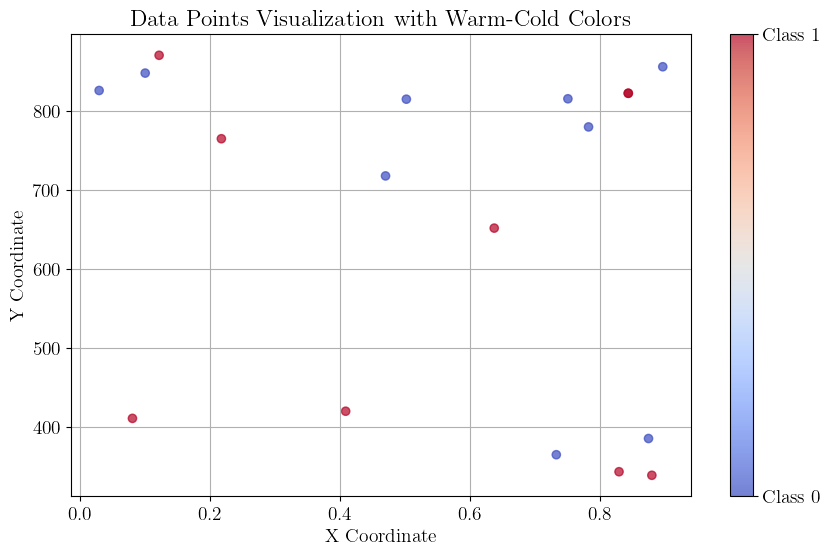

In [49]:
# Visualisierung
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Class 0', 'Class 1'])

plt.title('Data Points Visualization with Warm-Cold Colors')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

### Nur Bälle

In [50]:
# Merkmale auswählen
X = np.array(df[['ball_a','ball_b','ball_c']].apply(lambda x: np.array(x.tolist()).flatten(), axis=1).tolist())
y = df['classification'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
# Random Forest
y_rf = rf_classifier(X_train, X_test, y_train)
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf))

# Naive Bayes
y_g = g_classifier(X_train, X_test, y_train)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_g))

# kNN
y_knn = knn_classifier(X_train, X_test, y_train,3)
print("kNN Classification Report:\n", classification_report(y_test, y_knn))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       4.0
   macro avg       0.00      0.00      0.00       4.0
weighted avg       0.00      0.00      0.00       4.0

kNN Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50   

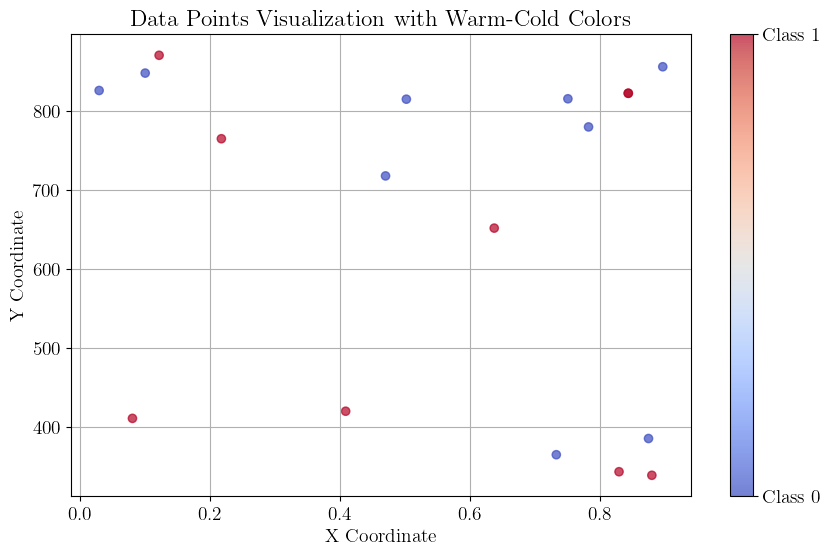

In [52]:
# Visualisierung
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Class 0', 'Class 1'])

plt.title('Data Points Visualization with Warm-Cold Colors')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

### Nur Hände

In [53]:
# Merkmale auswählen
X = np.array(df[['hand_left','hand_right']].apply(lambda x: np.array(x.tolist()).flatten(), axis=1).tolist())
y = df['classification'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
# Random Forest
y_rf = rf_classifier(X_train, X_test, y_train)
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf))

# Naive Bayes
y_g = g_classifier(X_train, X_test, y_train)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_g))

# kNN
y_knn = knn_classifier(X_train, X_test, y_train,3)
print("kNN Classification Report:\n", classification_report(y_test, y_knn))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4

kNN Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50   

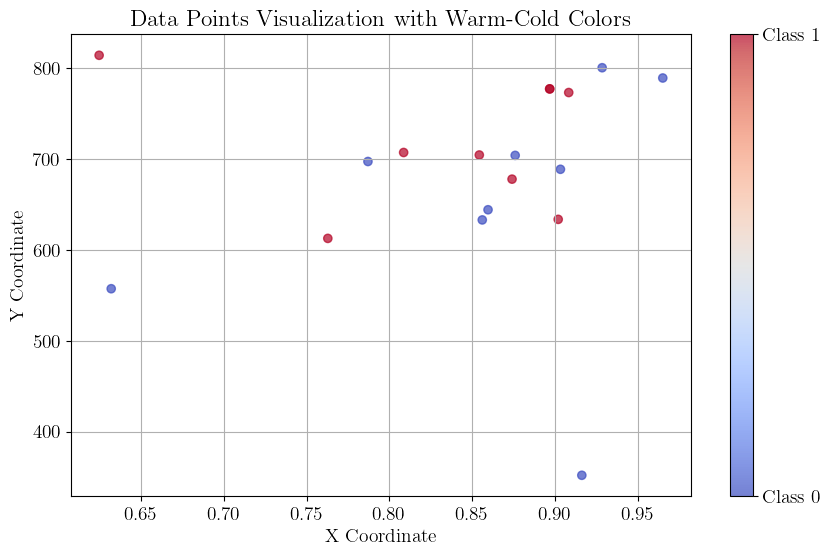

In [55]:
# Visualisierung
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Class 0', 'Class 1'])

plt.title('Data Points Visualization with Warm-Cold Colors')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

### Winkel der Ellenbogen

In [56]:
# Merkmale auswählen
# TODO
X = np.array(df[['ball_a','ball_b']].apply(lambda x: np.array(x.tolist()).flatten(), axis=1).tolist())
y = df['classification'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
# Random Forest
y_rf = rf_classifier(X_train, X_test, y_train)
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf))

# Naive Bayes
y_g = g_classifier(X_train, X_test, y_train)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_g))

# kNN
y_knn = knn_classifier(X_train, X_test, y_train,3)
print("kNN Classification Report:\n", classification_report(y_test, y_knn))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.00      0.00      0.00         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4

kNN Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       2.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       4.0
   macro avg       0.00   

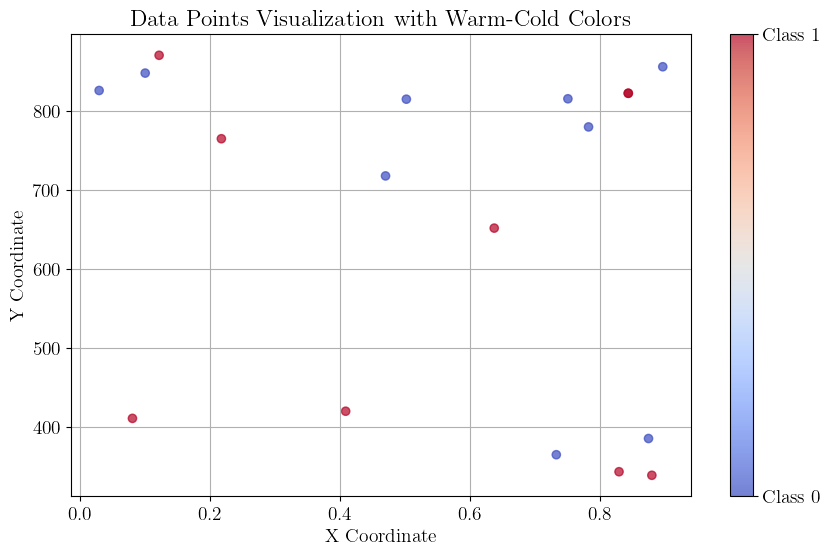

In [58]:
# Visualisierung
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Class 0', 'Class 1'])

plt.title('Data Points Visualization with Warm-Cold Colors')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

### Wurfhöhen

In [59]:
# Merkmale auswählen
# TODO
X = np.array(df[['hand_left','hand_right']].apply(lambda x: np.array(x.tolist()).flatten(), axis=1).tolist())
y = df['classification'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
# Random Forest
y_rf = rf_classifier(X_train, X_test, y_train)
print("Random Forest Classification Report:\n", classification_report(y_test, y_rf))

# Naive Bayes
y_g = g_classifier(X_train, X_test, y_train)
print("Naive Bayes Classification Report:\n", classification_report(y_test, y_g))

# kNN
y_knn = knn_classifier(X_train, X_test, y_train,3)
print("kNN Classification Report:\n", classification_report(y_test, y_knn))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50      0.50      0.50         4
weighted avg       0.50      0.50      0.50         4

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4

kNN Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.50      0.50      0.50         2

    accuracy                           0.50         4
   macro avg       0.50   

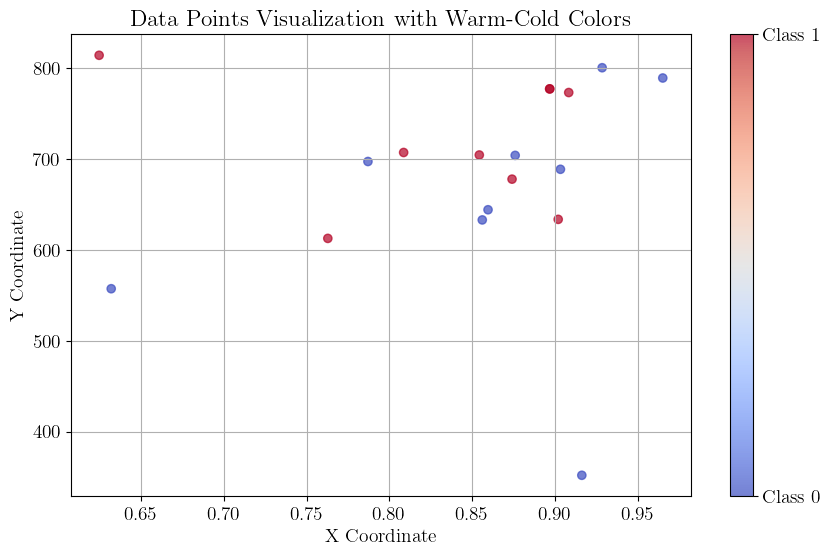

In [61]:
# Visualisierung
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)

cbar = plt.colorbar(scatter)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Class 0', 'Class 1'])

plt.title('Data Points Visualization with Warm-Cold Colors')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()